In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Configurações de visualização
%matplotlib inline
sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', None) # Mostrar todas as colunas

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [2]:
# Recarregando os dados para garantir a integridade
data_path = '../../data/raw/UNSW-NB15'

df_train = pd.read_csv(os.path.join(data_path, 'UNSW_NB15_training-set.csv'))
df_test = pd.read_csv(os.path.join(data_path, 'UNSW_NB15_testing-set.csv'))

df_train = df_train.drop('id', axis=1)
df_test = df_test.drop('id', axis=1)
df_train['service'] = df_train['service'].replace('-', 'unknown')
df_test['service'] = df_test['service'].replace('-', 'unknown')
X_train_full = df_train.drop(['attack_cat', 'label'], axis=1)
y_train_full = df_train['attack_cat']
X_test = df_test.drop(['attack_cat', 'label'], axis=1)
y_test = df_test['attack_cat']

# --- SIMULAÇÃO DO CENÁRIO SEMI-SUPERVISIONADO (CÓDIGO IDÊNTICO) ---
X_labeled, X_unlabeled, y_labeled, _ = train_test_split(
    X_train_full, y_train_full, test_size=0.90, random_state=42, stratify=y_train_full
)
X_train_semi = pd.concat([X_labeled, X_unlabeled], axis=0)
y_labeled_series = pd.Series(y_labeled, index=X_labeled.index)
y_unlabeled_series = pd.Series(-1, index=X_unlabeled.index)
y_train_semi = pd.concat([y_labeled_series, y_unlabeled_series], axis=0)

# --- PRÉ-PROCESSAMENTO (NOVA LÓGICA) ---

# 1. Definir o pré-processador
numeric_features = X_train_full.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train_full.select_dtypes(include=['object']).columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

# 2. Ajustar (fit) o pré-processador nos dados de treino COMPLETOS
print("Ajustando o pré-processador...")
preprocessor.fit(X_train_full)

# 3. Transformar os conjuntos de dados que serão usados no treinamento e teste
print("Transformando os dados...")
X_train_semi_processed = preprocessor.transform(X_train_semi)
X_test_processed = preprocessor.transform(X_test)

print("\nDados pré-processados e prontos para o Self-Training.")
print(f"Formato dos dados de treino processados: {X_train_semi_processed.shape}")
print(f"Formato dos dados de teste processados: {X_test_processed.shape}")

Ajustando o pré-processador...
Transformando os dados...

Dados pré-processados e prontos para o Self-Training.
Formato dos dados de treino processados: (175341, 194)
Formato dos dados de teste processados: (82332, 194)


In [3]:
# O estimador base agora é apenas o classificador, sem o pipeline
base_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')

# Criando o classificador Self-Training com o estimador base
self_training_model = SelfTrainingClassifier(
    base_estimator=base_rf, # Alterado para o estimador em vez do pipeline
    threshold=0.95,
    max_iter=10,
    verbose=True
)

print("Iniciando o treinamento do modelo Self-Training com Random Forest...")

# Treinando o modelo nos DADOS PROCESSADOS
# Nota: O y_train_semi ainda contém texto e o -1, o wrapper lida com isso internamente
self_training_model.fit(X_train_semi_processed, y_train_semi)

print("\nTreinamento concluído.")


# --- AVALIAÇÃO NO CONJUNTO DE TESTE ---

print("\nRealizando previsões no conjunto de teste PROCESSADO...")
y_pred = self_training_model.predict(X_test_processed)
print("Previsões concluídas.")

Iniciando o treinamento do modelo Self-Training com Random Forest...


C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\semi_supervised\_self_training.py:210: FutureWarning: `base_estimator` has been deprecated in 1.6 and will be removed in 1.8. Please use `estimator` instead.
  warn(


End of iteration 1, added 83557 new labels.
End of iteration 2, added 3547 new labels.
End of iteration 3, added 1927 new labels.
End of iteration 4, added 1474 new labels.
End of iteration 5, added 1131 new labels.
End of iteration 6, added 850 new labels.
End of iteration 7, added 656 new labels.
End of iteration 8, added 533 new labels.
End of iteration 9, added 354 new labels.
End of iteration 10, added 353 new labels.

Treinamento concluído.

Realizando previsões no conjunto de teste PROCESSADO...
Previsões concluídas.



--- Relatório de Classificação Binária (Self-Training RF) ---
              precision    recall  f1-score   support

  Normal (0)       0.95      0.77      0.85     37000
  Ataque (1)       0.84      0.97      0.90     45332

    accuracy                           0.88     82332
   macro avg       0.89      0.87      0.88     82332
weighted avg       0.89      0.88      0.88     82332



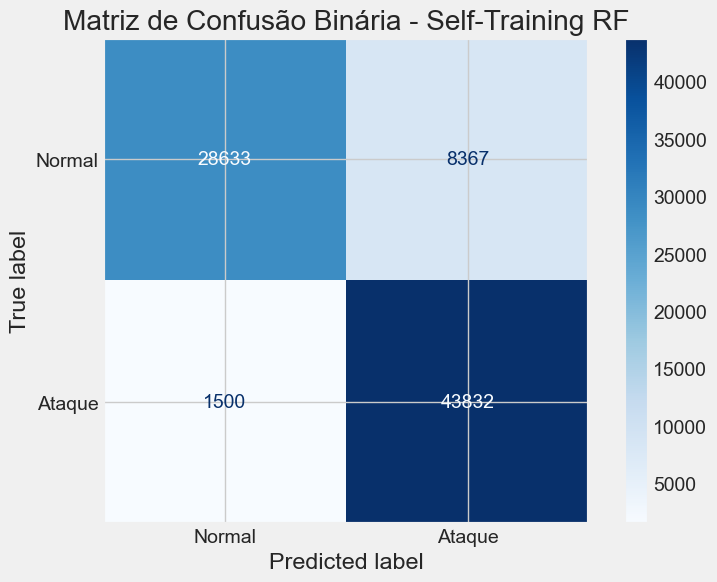

In [8]:
# --- Análise Binária (Normal vs. Ataque) ---
y_test_binary = np.where(y_test == 'Normal', 0, 1)
y_pred_binary = np.where(y_pred == 'Normal', 0, 1)

print("\n--- Relatório de Classificação Binária (Self-Training RF) ---")
print(classification_report(y_test_binary, y_pred_binary, target_names=['Normal (0)', 'Ataque (1)']))

cm_binary = confusion_matrix(y_test_binary, y_pred_binary)
disp_binary = ConfusionMatrixDisplay(confusion_matrix=cm_binary, display_labels=['Normal', 'Ataque'])
fig, ax = plt.subplots(figsize=(8, 6))
disp_binary.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusão Binária - Self-Training RF')
plt.savefig('confusion_matrix_multi_st_rf.png')
plt.show()


--- Relatório de Classificação por Tipo de Ataque (Self-Training RF) ---
                precision    recall  f1-score   support

        Normal       0.95      0.77      0.85     37000
      Backdoor       0.03      0.05      0.03       583
      Analysis       0.01      0.01      0.01       677
       Fuzzers       0.30      0.53      0.39      6062
     Shellcode       0.46      0.46      0.46       378
Reconnaissance       0.81      0.79      0.80      3496
      Exploits       0.65      0.73      0.69     11132
           DoS       0.27      0.37      0.31      4089
         Worms       1.00      0.02      0.04        44
       Generic       1.00      0.96      0.98     18871

      accuracy                           0.76     82332
     macro avg       0.55      0.47      0.46     82332
  weighted avg       0.82      0.76      0.78     82332



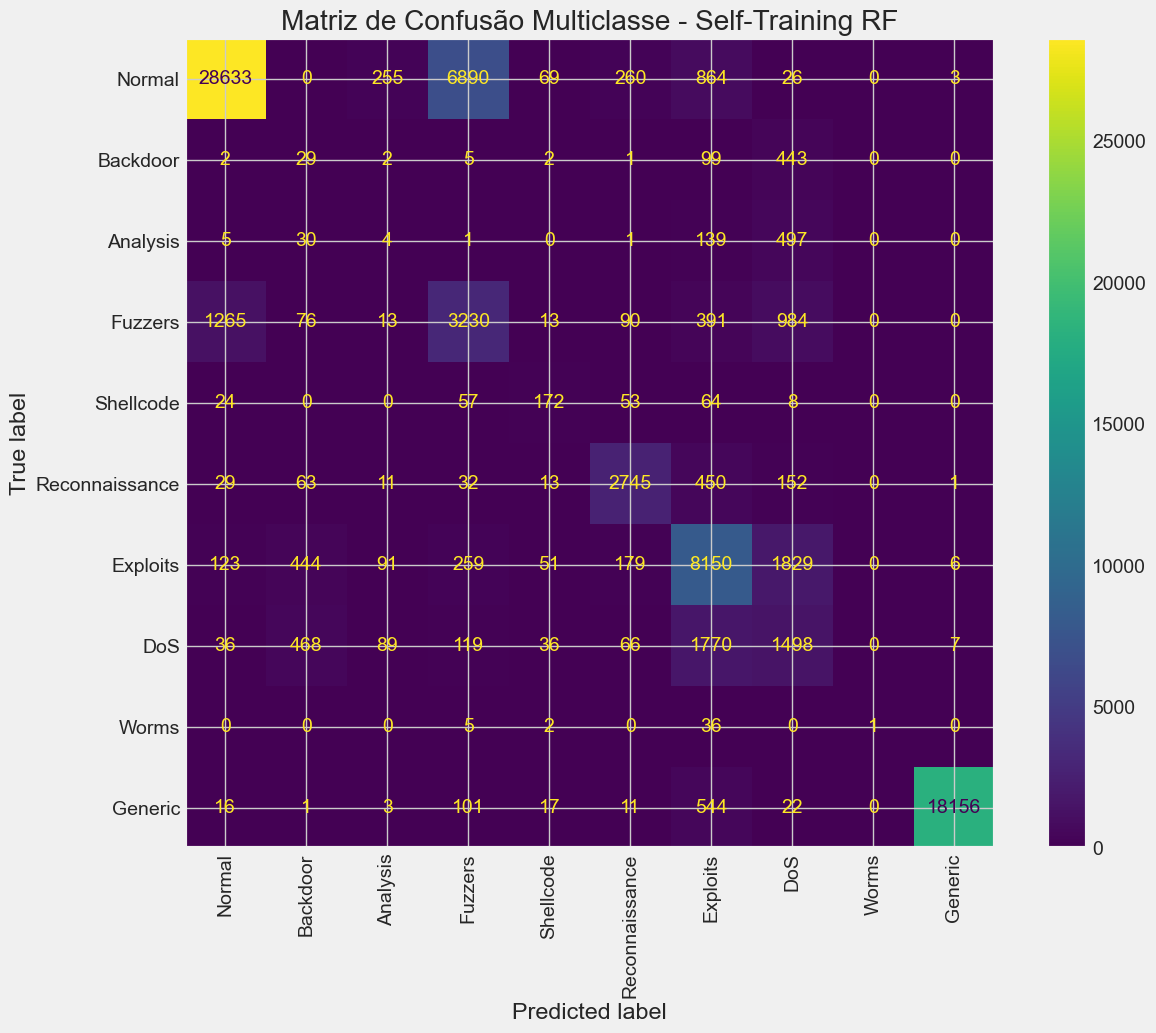

In [9]:
# --- Análise Multiclasse (Tipo de Ataque) ---
class_names = df_train['attack_cat'].unique()
print("\n--- Relatório de Classificação por Tipo de Ataque (Self-Training RF) ---")
print(classification_report(y_test, y_pred, labels=class_names))

cm_multi = confusion_matrix(y_test, y_pred, labels=class_names)
disp_multi = ConfusionMatrixDisplay(confusion_matrix=cm_multi, display_labels=class_names)
fig, ax = plt.subplots(figsize=(12, 10))
disp_multi.plot(ax=ax, cmap='viridis', xticks_rotation='vertical')
plt.title('Matriz de Confusão Multiclasse - Self-Training RF')
plt.savefig('confusion_matrix_atks_multi_st_rf.png')
plt.show()

In [7]:
try:
    # Salvar o Pré-processador
    joblib.dump(preprocessor, 'st_rf_preprocessor_unsw_nb15.joblib')
    print("Objeto 'preprocessor' salvo com sucesso.")
    
    # Salvar o Modelo Self-Training treinado
    joblib.dump(self_training_model, 'st_rf_model_unsw_nb15.joblib')
    print("Modelo 'self_training_model' salvo com sucesso.")

except Exception as e:
    print(f"Ocorreu um erro ao salvar os arquivos: {e}")

Objeto 'preprocessor' salvo com sucesso.
Modelo 'self_training_model' salvo com sucesso.
